In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:

df = pd.read_csv('Breast Cancer Data.csv')

df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

(None,
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
 0    842302         M        17.99         10.38          122.80     1001.0   
 1    842517         M        20.57         17.77          132.90     1326.0   
 2  84300903         M        19.69         21.25          130.00     1203.0   
 3  84348301         M        11.42         20.38           77.58      386.1   
 4  84358402         M        20.29         14.34          135.10     1297.0   
 
    smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
 0          0.11840           0.27760          0.3001              0.14710   
 1          0.08474           0.07864          0.0869              0.07017   
 2          0.10960           0.15990          0.1974              0.12790   
 3          0.14250           0.28390          0.2414              0.10520   
 4          0.10030           0.13280          0.1980              0.10430   
 
    ...  texture_worst  perimeter_worst  

In [30]:


df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]


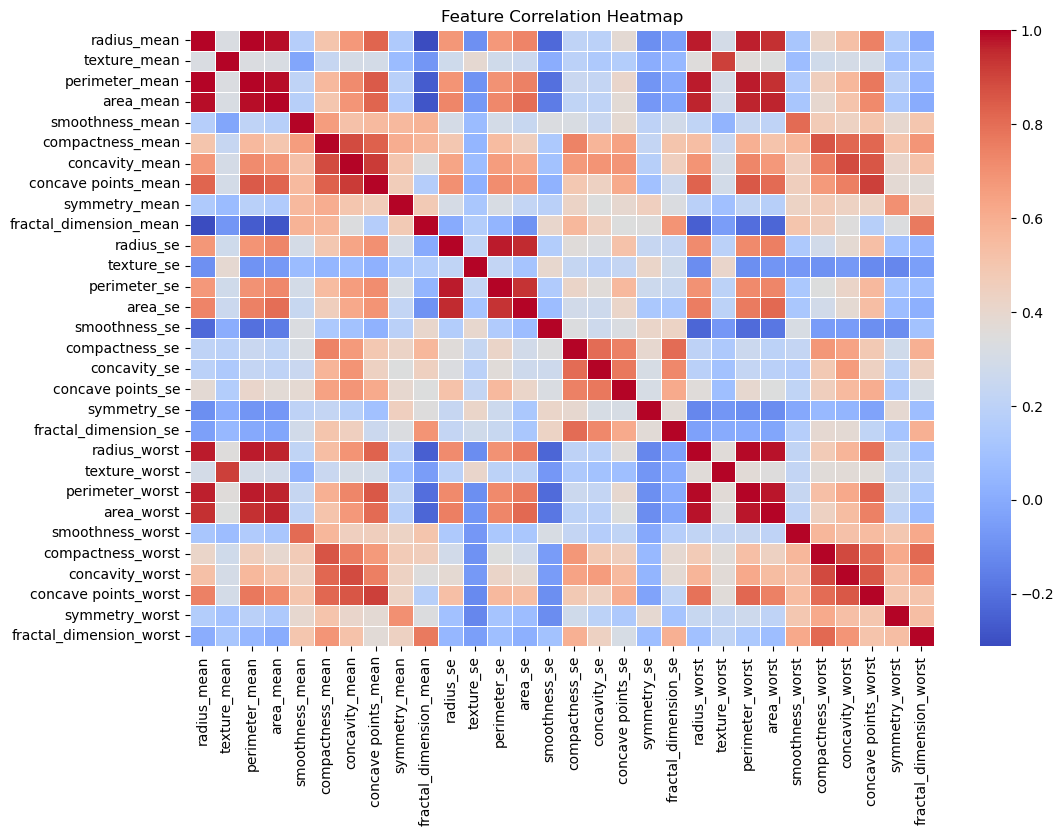

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

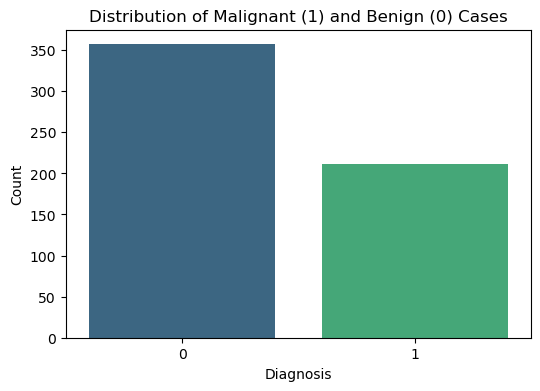

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette="viridis")
plt.title("Distribution of Malignant (1) and Benign (0) Cases")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

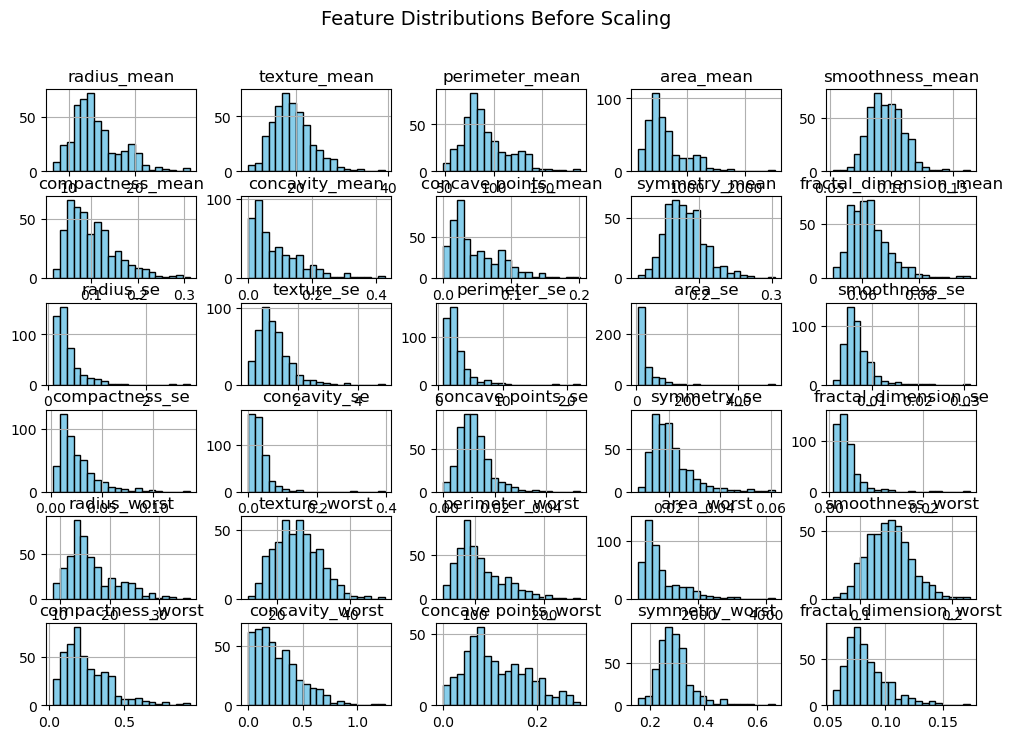

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.hist(figsize=(12,8), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Feature Distributions Before Scaling", fontsize=14)
plt.show()

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

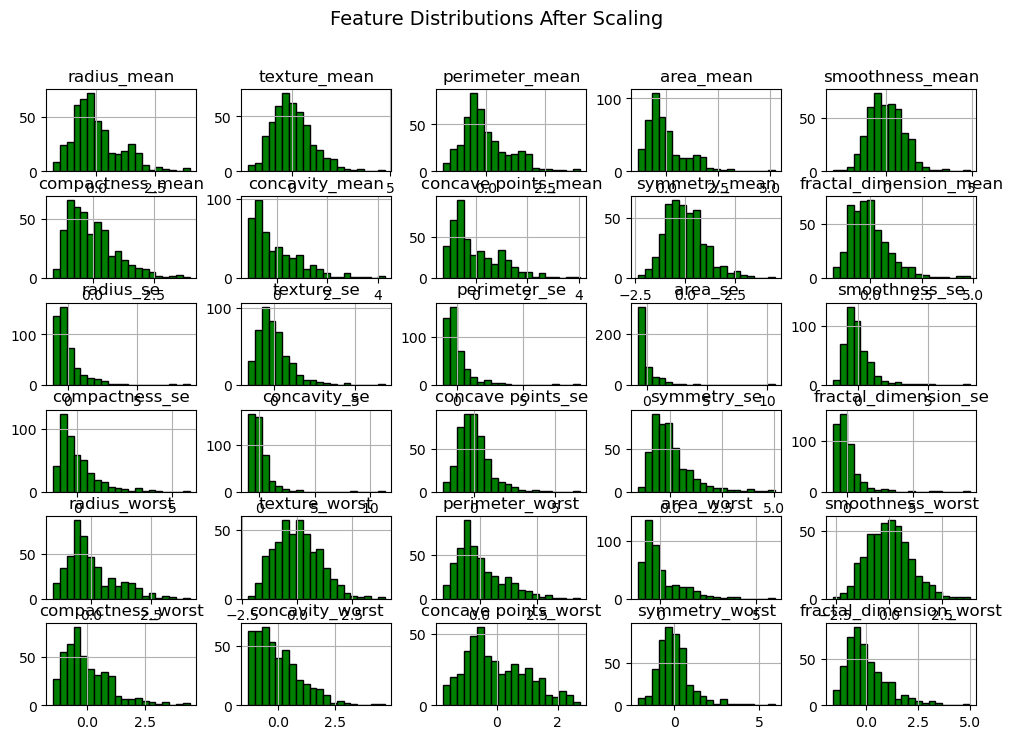

In [19]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).hist(figsize=(12,8), bins=20, color="green", edgecolor="black")
plt.suptitle("Feature Distributions After Scaling", fontsize=14)
plt.show()

In [59]:



model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")



Training Accuracy: 0.9868
Testing Accuracy: 0.9737


In [34]:



def print_classification_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    return df_report


def print_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, 
                         index=["Actual Benign (0)", "Actual Malignant (1)"], 
                         columns=["Predicted Benign (0)", "Predicted Malignant (1)"])
    return cm_df


df_class_report = print_classification_report(y_test, y_pred)
df_conf_matrix = print_confusion_matrix(y_test, y_pred)

df_class_report, df_conf_matrix




(              precision    recall  f1-score     support
 0              0.972222  0.985915  0.979021   71.000000
 1              0.976190  0.953488  0.964706   43.000000
 accuracy       0.973684  0.973684  0.973684    0.973684
 macro avg      0.974206  0.969702  0.971863  114.000000
 weighted avg   0.973719  0.973684  0.973621  114.000000,
                       Predicted Benign (0)  Predicted Malignant (1)
 Actual Benign (0)                       70                        1
 Actual Malignant (1)                     2                       41)

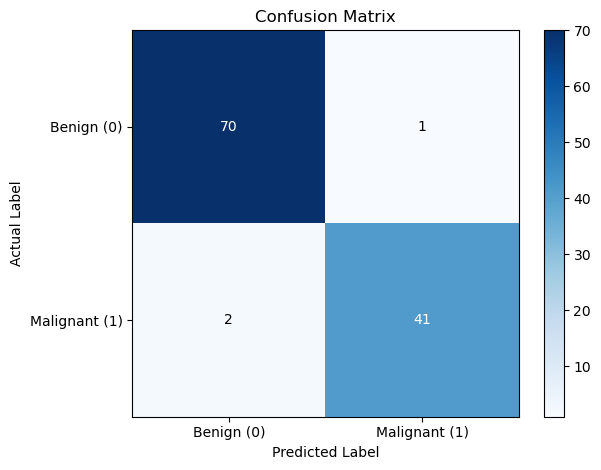

In [60]:

conf_matrix = confusion_matrix(y_test, y_pred)

plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, labels=["Benign (0)", "Malignant (1)"], rotation=0)
plt.yticks(tick_marks, labels=["Benign (0)", "Malignant (1)"])


thresh = conf_matrix.max() / 2.
for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             ha="center", va="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()




In [25]:


from sklearn.feature_selection import SelectKBest, f_classif


selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_selected, y_train)


y_pred_best = best_model.predict(X_test_selected)

train_accuracy_best = best_model.score(X_train_selected, y_train)
test_accuracy_best = best_model.score(X_test_selected, y_test)

print(f"Training Accuracy (Improved): {train_accuracy_best:.4f}")
print(f"Testing Accuracy (Improved): {test_accuracy_best:.4f}")



Training Accuracy (Improved): 0.9604
Testing Accuracy (Improved): 0.9737


In [55]:
def print_classification_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    return df_report


def print_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, 
                         index=["Actual Benign (0)", "Actual Malignant (1)"], 
                         columns=["Predicted Benign (0)", "Predicted Malignant (1)"])
    return cm_df


df_class_report = print_classification_report(y_test, y_pred_best)
df_conf_matrix = print_confusion_matrix(y_test, y_pred_best)

df_class_report, df_conf_matrix



(              precision    recall  f1-score     support
 0              0.985714  0.971831  0.978723   71.000000
 1              0.954545  0.976744  0.965517   43.000000
 accuracy       0.973684  0.973684  0.973684    0.973684
 macro avg      0.970130  0.974288  0.972120  114.000000
 weighted avg   0.973958  0.973684  0.973742  114.000000,
                       Predicted Benign (0)  Predicted Malignant (1)
 Actual Benign (0)                       69                        2
 Actual Malignant (1)                     1                       42)

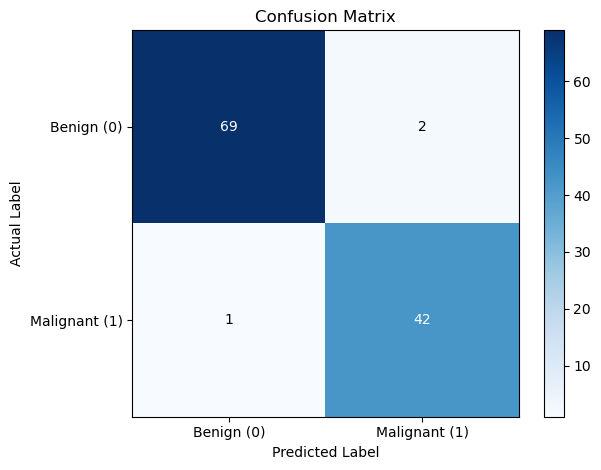

In [54]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


conf_matrix_best = confusion_matrix(y_test, y_pred_best)


plt.imshow(conf_matrix_best, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()


tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, labels=["Benign (0)", "Malignant (1)"], rotation=0)
plt.yticks(tick_marks, labels=["Benign (0)", "Malignant (1)"])


thresh = conf_matrix_best.max() / 2.
for i, j in np.ndindex(conf_matrix_best.shape):
    plt.text(j, i, format(conf_matrix_best[i, j], 'd'),
             ha="center", va="center",
             color="white" if conf_matrix_best[i, j] > thresh else "black")


plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()